In [39]:
import numpy as np
import matplotlib.pyplot as plt

In [40]:
# вспомогательная функция для стабильного сложения вероятностей в log-space
def log_sum_exp(log_probs):
    max_val = np.max(log_probs)
    if max_val == -np.inf:
        return -np.inf
    return max_val + np.log(np.sum(np.exp(log_probs - max_val)))

# алгоритм витерби - находит наиболее вероятную последовательность состояний
def viterbi(log_A, log_B, log_pi, obs_indices):
    T = len(obs_indices)
    N = len(log_pi)
    
    delta = np.full((T, N), -np.inf)
    psi = np.zeros((T, N), dtype=int)
    
    # инициализация
    delta[0] = log_pi + log_B[:, obs_indices[0]]
    
    # рекурсия
    for t in range(1, T):
        for j in range(N):
            scores = delta[t-1] + log_A[:, j]
            psi[t, j] = np.argmax(scores)
            delta[t, j] = scores[psi[t, j]] + log_B[j, obs_indices[t]]
    
    # обратный ход
    path = [0] * T
    path[T-1] = np.argmax(delta[T-1])
    for t in range(T-2, -1, -1):
        path[t] = psi[t+1, path[t+1]]
        
    return path, delta[T-1, path[T-1]]

In [41]:
# алгоритм forward
def forward(log_A, log_B, log_pi, obs_indices):
    T = len(obs_indices)
    N = len(log_pi)
    alpha = np.full((T, N), -np.inf)
    
    alpha[0] = log_pi + log_B[:, obs_indices[0]]
    
    for t in range(1, T):
        for j in range(N):
            alpha[t, j] = log_sum_exp(alpha[t-1] + log_A[:, j]) + log_B[j, obs_indices[t]]
            
    log_prob_total = log_sum_exp(alpha[T-1])
    return alpha, log_prob_total

In [42]:
# алгоритм backward
def backward(log_A, log_B, obs_indices):
    T = len(obs_indices)
    N = log_A.shape[0]
    beta = np.full((T, N), -np.inf)
    
    beta[T-1] = 0
    
    for t in range(T-2, -1, -1):
        for i in range(N):
            beta[t, i] = log_sum_exp(log_A[i, :] + log_B[:, obs_indices[t+1]] + beta[t+1, :])
            
    return beta

In [43]:
# параметры модели из статьи
states = ['E', '5', 'I']
obs_symbols = ['A', 'C', 'G', 'T']

# матрица переходов A
# из E: в E (0.9), в 5 (0.1)
# из 5: в I (1.0)
# из I: в I (0.9)
A = np.array([
    [0.9, 0.1, 0.0],
    [0.0, 0.0, 1.0],
    [0.0, 0.0, 0.9]
])

# матрица эмиссий B
# E: равномерное распределение
# 5: почти всегда G (0.95)
# I: A и T чаще
B = np.array([
    [0.25, 0.25, 0.25, 0.25],
    [0.05, 0.0,  0.95, 0.0 ],
    [0.4,  0.1,  0.1,  0.4 ]
])

# начальные вероятности
pi = np.array([1.0, 0.0, 0.0])

# последовательность из статьи
observations_raw = "CTTCATGTGAAAGCAGACGTAAGTCA"

# перевод в log-space
log_A = np.log(A + 1e-10)
log_B = np.log(B + 1e-10)
log_pi = np.log(pi + 1e-10)

# перевод наблюдений в индексы
obs_map = {s: i for i, s in enumerate(obs_symbols)}
obs_indices = [obs_map[o] for o in observations_raw]


In [45]:
print("Витерби")
best_path_indices, log_prob_viterbi = viterbi(log_A, log_B, log_pi, obs_indices)
best_path_names = [states[i] for i in best_path_indices]

print(f"последовательность наблюдений: {observations_raw}")
print(f"наиболее вероятный путь: {''.join(best_path_names)}")
print(f"log-вероятность: {log_prob_viterbi:.4f}")
print(f"вероятность: {np.exp(log_prob_viterbi):.6e}")

Витерби
последовательность наблюдений: CTTCATGTGAAAGCAGACGTAAGTCA
наиболее вероятный путь: EEEEEEEEEEEEEEEEEEEEEEEEEE
log-вероятность: -38.6777
вероятность: 1.594054e-17


In [48]:
print("\nForward")
alpha, log_prob_total = forward(log_A, log_B, log_pi, obs_indices)

print(f"log P(O): {log_prob_total:.4f}")
print(f"P(O): {np.exp(log_prob_total):.6e}")


Forward
log P(O): -37.6748
P(O): 4.345329e-17



Графики
максимумы:
состояние E: t=1, вероятность=1.0000
состояние 5: t=19, вероятность=0.2887
состояние I: t=24, вероятность=0.6250


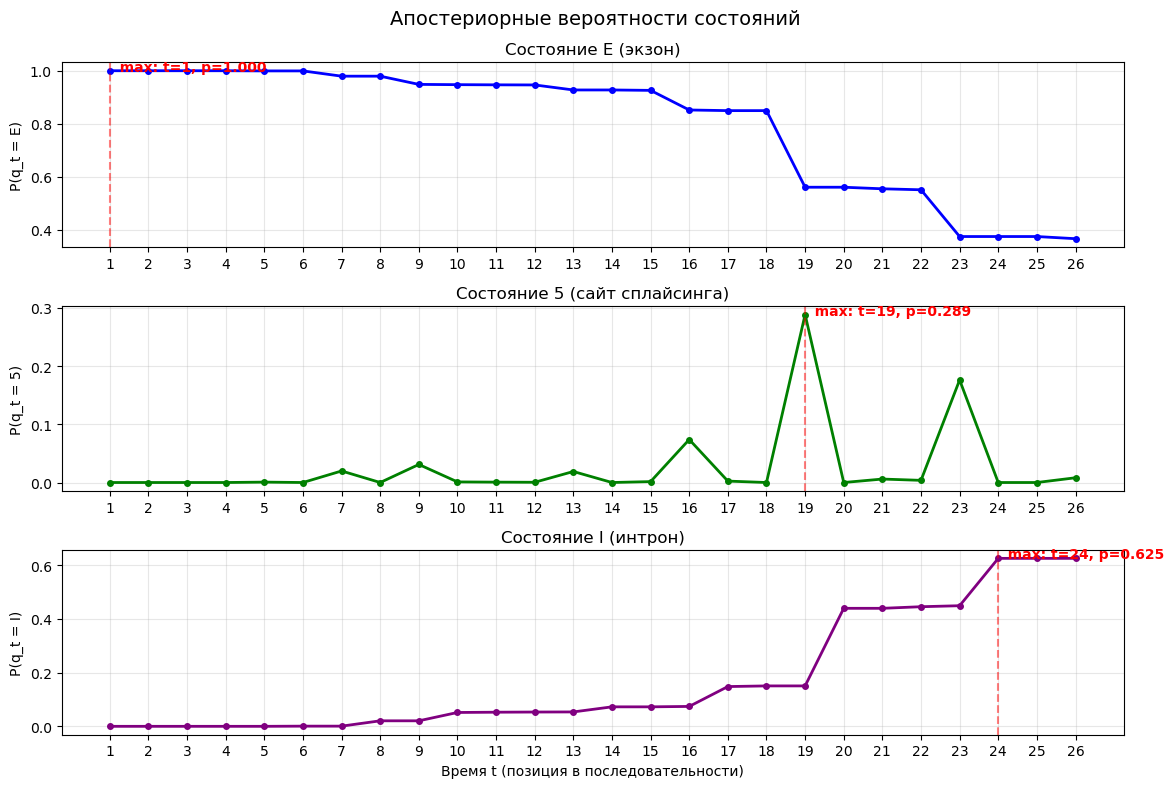

In [47]:
# задание 3: графики (forward-backward)
print("\nГрафики")

beta = backward(log_A, log_B, obs_indices)

# gamma[t,i] = P(q_t = i | O, lambda)
log_gamma = alpha + beta - log_prob_total
gamma = np.exp(log_gamma)
# индексы состояний
idx_E = 0
idx_5 = 1
idx_I = 2

t_steps = list(range(1, len(observations_raw) + 1))
prob_E = gamma[:, idx_E]
prob_5 = gamma[:, idx_5]
prob_I = gamma[:, idx_I]

# поиск максимумов
max_t_E = np.argmax(prob_E) + 1
max_val_E = prob_E[max_t_E - 1]

max_t_5 = np.argmax(prob_5) + 1
max_val_5 = prob_5[max_t_5 - 1]

max_t_I = np.argmax(prob_I) + 1
max_val_I = prob_I[max_t_I - 1]

print(f"максимумы:")
print(f"состояние E: t={max_t_E}, вероятность={max_val_E:.4f}")
print(f"состояние 5: t={max_t_5}, вероятность={max_val_5:.4f}")
print(f"состояние I: t={max_t_I}, вероятность={max_val_I:.4f}")

# построение графиков
fig, axs = plt.subplots(3, 1, figsize=(12, 8))
fig.suptitle('Апостериорные вероятности состояний', fontsize=14)

# график для состояния E
axs[0].plot(t_steps, prob_E, 'b-o', linewidth=2, markersize=4)
axs[0].axvline(max_t_E, color='red', linestyle='--', alpha=0.5)
axs[0].text(max_t_E, max_val_E, f'  max: t={max_t_E}, p={max_val_E:.3f}', 
            color='red', fontweight='bold')
axs[0].set_ylabel('P(q_t = E)')
axs[0].set_title('Состояние E (экзон)')
axs[0].grid(True, alpha=0.3)
axs[0].set_xticks(t_steps)

# график для состояния 5
axs[1].plot(t_steps, prob_5, 'g-o', linewidth=2, markersize=4)
axs[1].axvline(max_t_5, color='red', linestyle='--', alpha=0.5)
axs[1].text(max_t_5, max_val_5, f'  max: t={max_t_5}, p={max_val_5:.3f}', 
            color='red', fontweight='bold')
axs[1].set_ylabel('P(q_t = 5)')
axs[1].set_title('Состояние 5 (сайт сплайсинга)')
axs[1].grid(True, alpha=0.3)
axs[1].set_xticks(t_steps)

# график для состояния I
axs[2].plot(t_steps, prob_I, 'purple', marker='o', linewidth=2, markersize=4)
axs[2].axvline(max_t_I, color='red', linestyle='--', alpha=0.5)
axs[2].text(max_t_I, max_val_I, f'  max: t={max_t_I}, p={max_val_I:.3f}', 
            color='red', fontweight='bold')
axs[2].set_ylabel('P(q_t = I)')
axs[2].set_title('Состояние I (интрон)')
axs[2].set_xlabel('Время t (позиция в последовательности)')
axs[2].grid(True, alpha=0.3)
axs[2].set_xticks(t_steps)

plt.tight_layout()
plt.show()